# YouTube Video Performance Analysis

## 📌 Project Objective

To analyze YouTube Shorts performance and identify key factors influencing engagement, retention, and subscriber conversion.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv(r"E:\data analyst bootcamp\Python\youtube_eda_project\data\MainTable data.csv")
df.head()

,Content,Video title,Video publish time,Duration,Engaged views,Average view duration,Stayed to watch (%),Unique viewers,Subscribers gained,Subscribers lost,Likes,Dislikes,Shares,Comments added,Views,Watch time (hours),Subscribers,Impressions,Impressions click-through rate (%)
0,Total,NaN,NaN,NaN,16784,0:00:09,39.24,14971,36,4,576,9,20,37,50905,57.3498,32,19225,3.14
1,CbomK7CB_a8,Ever Craved Something SO Bad… But Then It Tast...,"Mar 9, 2026",8.0,4882,0:00:09,73.76,4716,0,0,85,2,0,3,9264,13.5991,0,1096,5.02
2,0KAKl2p1Zhc,Some People Just Bring Good Energy,"Mar 22, 2026",10.0,615,0:00:08,47.20,582,0,0,19,1,0,3,1512,1.7964,0,784,2.30
3,c3xqDS6pUZ4,Love is remembering little things ❤️ #relatable,"Mar 7, 2026",8.0,594,0:00:09,36.20,527,0,0,20,0,0,2,1873,1.9057,0,1480,2.30
4,vSNYLc_6Qmg,The Beauty of Unexpected Kindness,"Mar 17, 2026",17.0,578,0:00:11,27.58,518,2,0,23,1,1,3,2173,2.4575,2,801,3.87


In [4]:
## Fix

df = df[df['Content'] != 'Total']

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 1 to 24
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Content                             24 non-null     str           
 1   Video title                         24 non-null     str           
 2   Video publish time                  24 non-null     datetime64[us]
 3   Duration                            24 non-null     float64       
 4   Engaged views                       24 non-null     int64         
 5   Average view duration               0 non-null      float64       
 6   Stayed to watch (%)                 23 non-null     float64       
 7   Unique viewers                      24 non-null     int64         
 8   Subscribers gained                  24 non-null     int64         
 9   Subscribers lost                    24 non-null     int64         
 10  Likes                               24 

In [46]:
df.isnull().sum()

Content                                0
Video title                            0
Video publish time                     0
Duration                               0
Engaged views                          0
Average view duration                 24
Stayed to watch (%)                    1
Unique viewers                         0
Subscribers gained                     0
Subscribers lost                       0
Likes                                  0
Dislikes                               0
Shares                                 0
Comments added                         0
Views                                  0
Watch time (hours)                     0
Subscribers                            0
Impressions                            0
Impressions click-through rate (%)     0
publish_day                            0
publish_month                          0
engagement_rate                        0
engagement_rate (%)                    0
dtype: int64

In [ ]:
df.drop('engagement_rate',axis=1, inplace=True)

In [90]:
df.columns

Index(['Content', 'Video title', 'Video publish time', 'Duration',
       'Engaged views', 'Stayed to watch (%)', 'Unique viewers',
       'Subscribers gained', 'Subscribers lost', 'Likes', 'Dislikes', 'Shares',
       'Comments added', 'Views', 'Watch time (hours)', 'Subscribers',
       'Impressions', 'Impressions click-through rate (%)', 'publish_day',
       'publish_month', 'engagement_rate (%)'],
      dtype='str')

In [91]:
df.isnull().sum()

Content                               0
Video title                           0
Video publish time                    0
Duration                              0
Engaged views                         0
Stayed to watch (%)                   0
Unique viewers                        0
Subscribers gained                    0
Subscribers lost                      0
Likes                                 0
Dislikes                              0
Shares                                0
Comments added                        0
Views                                 0
Watch time (hours)                    0
Subscribers                           0
Impressions                           0
Impressions click-through rate (%)    0
publish_day                           0
publish_month                         0
engagement_rate (%)                   0
dtype: int64

In [63]:
#Handle small missing value

df['Stayed to watch (%)'].fillna(df['Stayed to watch (%)'].mean(), inplace=True)


C:\Users\Dell\AppData\Local\Temp\ipykernel_14996\2180719254.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Stayed to watch (%)'].fillna(df['Stayed to watch (%)'].mean(), inplace=True)


1     73.760000
2     47.200000
3     36.200000
4     27.580000
5     37.000000
6     26.950000
7     29.360000
8     48.640000
9     37.800000
10    44.840000
11    35.620000
12    41.840000
13    34.210000
14    41.800000
15    33.930000
16    35.540000
17    24.580000
18    30.170000
19    19.140000
20    40.280000
21    31.840000
22    32.740000
23    72.220000
24    38.401739
Name: Stayed to watch (%), dtype: float64

In [69]:
df['Stayed to watch (%)']=df['Stayed to watch (%)'].fillna(df['Stayed to watch (%)'].mean())

In [70]:
df[df['Stayed to watch (%)'].isnull()]

,Content,Video title,Video publish time,Duration,Engaged views,Stayed to watch (%),Unique viewers,Subscribers gained,Subscribers lost,Likes,...,Comments added,Views,Watch time (hours),Subscribers,Impressions,Impressions click-through rate (%),publish_day,publish_month,engagement_rate,engagement_rate (%)


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 1 to 24
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Content                             24 non-null     str           
 1   Video title                         24 non-null     str           
 2   Video publish time                  24 non-null     datetime64[us]
 3   Duration                            24 non-null     float64       
 4   Engaged views                       24 non-null     int64         
 5   Stayed to watch (%)                 24 non-null     float64       
 6   Unique viewers                      24 non-null     int64         
 7   Subscribers gained                  24 non-null     int64         
 8   Subscribers lost                    24 non-null     int64         
 9   Likes                               24 non-null     int64         
 10  Dislikes                            24 

In [76]:
df.duplicated()

1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
dtype: bool

In [93]:
# Converting Date Column
# Selecting Columns
# Converting to Numeric
# Converted the publish time column to datetime format to enable time-based analysis.

df['Video publish time'] = pd.to_datetime(df['Video publish time'])

cols = ['Engaged views','Unique viewers',
        'Subscribers gained', 'Likes', 'Dislikes']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')




In [94]:
df.head()

,Content,Video title,Video publish time,Duration,Engaged views,Stayed to watch (%),Unique viewers,Subscribers gained,Subscribers lost,Likes,...,Shares,Comments added,Views,Watch time (hours),Subscribers,Impressions,Impressions click-through rate (%),publish_day,publish_month,engagement_rate (%)
1,CbomK7CB_a8,Ever Craved Something SO Bad… But Then It Tast...,2026-03-09,8.0,4882,73.76,4716,0,0,85,...,0,3,9264,13.5991,0,1096,5.02,Monday,3,0.949914
2,0KAKl2p1Zhc,Some People Just Bring Good Energy,2026-03-22,10.0,615,47.20,582,0,0,19,...,0,3,1512,1.7964,0,784,2.30,Sunday,3,1.455026
3,c3xqDS6pUZ4,Love is remembering little things ❤️ #relatable,2026-03-07,8.0,594,36.20,527,0,0,20,...,0,2,1873,1.9057,0,1480,2.30,Saturday,3,1.174586
4,vSNYLc_6Qmg,The Beauty of Unexpected Kindness,2026-03-17,17.0,578,27.58,518,2,0,23,...,1,3,2173,2.4575,2,801,3.87,Tuesday,3,1.242522
5,jx0owrWV2Sw,Just Because You’re Different Doesn’t Mean You...,2026-03-15,6.0,562,37.00,537,2,0,19,...,0,2,1940,1.5234,2,691,1.30,Sunday,3,1.082474


In [95]:
## Feature engineering

df['publish_day'] = df['Video publish time'].dt.day_name()
df['publish_month'] = df['Video publish time'].dt.month

In [ ]:
# Which video got most subscibers?

df.sort_values(by='Subscribers gained', ascending=False).head(1)

,Content,Video title,Video publish time,Duration,Engaged views,Stayed to watch (%),Unique viewers,Subscribers gained,Subscribers lost,Likes,...,Comments added,Views,Watch time (hours),Subscribers,Impressions,Impressions click-through rate (%),publish_day,publish_month,engagement_rate,engagement_rate (%)
6,wEiURcD9fAI,When you start celebrating the little things l...,2026-03-06,8.0,557,26.95,493,4,0,21,...,2,2365,2.275,4,1397,2.29,Friday,3,0.009725,0.972516


In [ ]:
## Top 5 videos

top5 = df.sort_values(by='Engaged views', ascending=False).head(5)
top5[['Video title','Engaged views','Likes']]



,Video title,Engaged views,Likes
1,Ever Craved Something SO Bad… But Then It Tast...,4882,85
2,Some People Just Bring Good Energy,615,19
3,Love is remembering little things ❤️ #relatable,594,20
4,The Beauty of Unexpected Kindness,578,23
5,Just Because You’re Different Doesn’t Mean You...,562,19


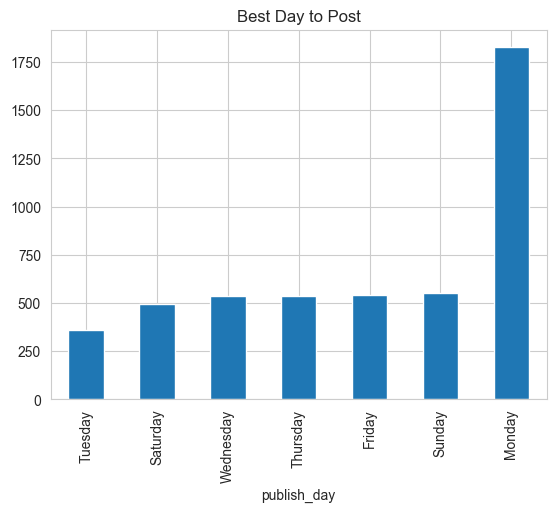

In [11]:
## Day-wise performance

df.groupby('publish_day')['Engaged views'].mean().sort_values().plot(kind='bar')
plt.title("Best Day to Post")
plt.show()

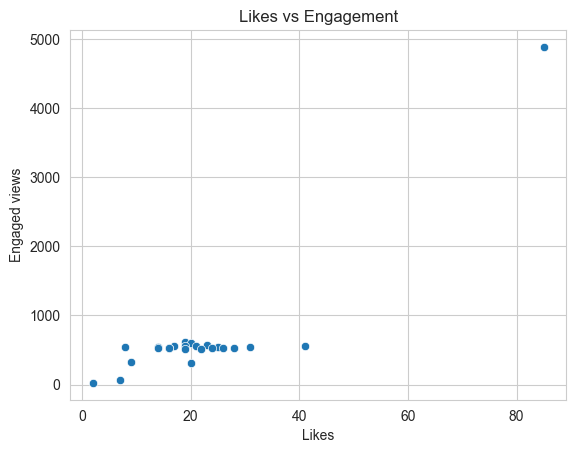

In [12]:
## Likes vs Views

sns.scatterplot(x='Likes', y='Engaged views', data=df)
plt.title("Likes vs Engagement")
plt.show()

In [79]:
# value counts for patterns

df['publish_day'].value_counts()

publish_day
Sunday       5
Saturday     4
Tuesday      4
Friday       4
Monday       3
Thursday     2
Wednesday    2
Name: count, dtype: int64

## Key Insights

- Videos with higher likes show strong engagement
- Few videos dominate overall performance
- Certain days result in higher average engagement
- Short videos tend to have consistent engagement

In [ ]:
## Why do some videos fail? low Likes? Low views? Low CTR?

low5 = df.sort_values(by='Engaged views', ascending=True).head(5)

low5[['Video title','Engaged views','Likes']]

,Video title,Engaged views,Likes
24,B.com 3rd year project. Topic - World is a mirror,23,2
23,I don’t shut down. I shut people down.,65,7
22,The Problem With Motivation,313,20
21,The Beauty of People Who Check on You,320,9
20,"You Are Not Your Thoughts, Read This Twice",514,22


e:\data analyst bootcamp\Python\youtube_eda_project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127474 (\N{REGIONAL INDICATOR SYMBOL LETTER M}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
e:\data analyst bootcamp\Python\youtube_eda_project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127486 (\N{REGIONAL INDICATOR SYMBOL LETTER Y}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


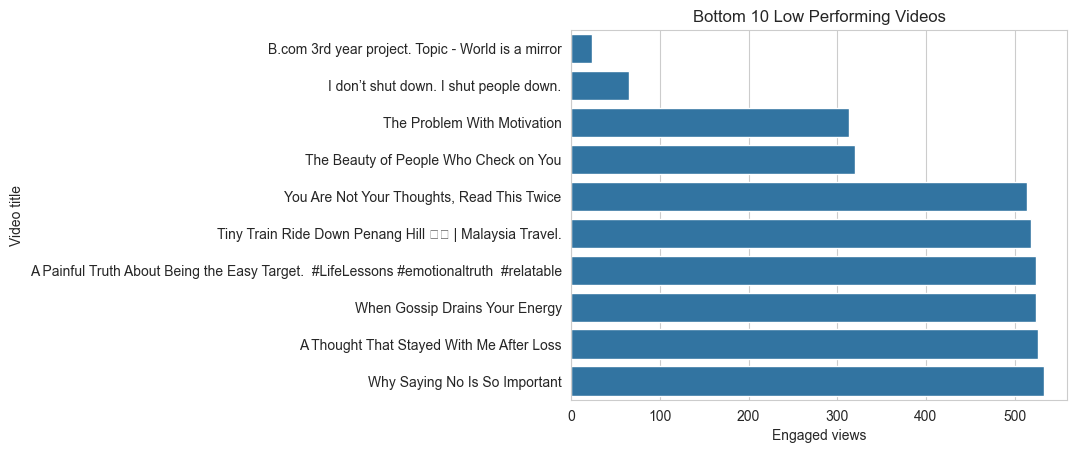

In [16]:
# Visualize

sns.barplot(x='Engaged views', y='Video title', data=low10)
plt.title("Bottom 10 Low Performing Videos")
plt.show()

In [100]:
df.describe()

,Video publish time,Duration,Engaged views,Stayed to watch (%),Unique viewers,Subscribers gained,Subscribers lost,Likes,Dislikes,Shares,Comments added,Views,Watch time (hours),Subscribers,Impressions,Impressions click-through rate (%),publish_month,engagement_rate (%)
count,24,24.000000,24.000000,24.000000,24.000000,24.000000,24.0,24.000000,24.000000,24.000000,24.000000,24.00000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,2025-11-12 11:00:00,10.916667,665.958333,38.401739,622.958333,0.916667,0.0,21.916667,0.375000,0.416667,1.666667,1968.50000,2.152738,0.916667,771.916667,3.317500,2.916667,1.883948
min,2018-02-20 00:00:00,5.000000,23.000000,19.140000,13.000000,0.000000,0.0,2.000000,0.000000,0.000000,0.000000,23.00000,0.133600,0.000000,207.000000,0.960000,2.000000,0.643777
25%,2026-03-08 00:00:00,8.000000,522.750000,31.422500,478.250000,0.000000,0.0,15.500000,0.000000,0.000000,1.000000,1421.50000,1.548525,0.000000,531.250000,1.710000,3.000000,0.967340
50%,2026-03-16 00:00:00,9.000000,535.000000,35.910000,502.500000,0.000000,0.0,19.500000,0.000000,0.000000,2.000000,1778.50000,1.773950,0.000000,625.000000,2.310000,3.000000,1.296937
75%,2026-03-20 06:00:00,10.000000,554.750000,41.810000,510.500000,2.000000,0.0,24.250000,1.000000,1.000000,2.000000,2005.25000,2.030050,2.000000,1006.000000,3.517500,3.000000,1.705826
max,2026-03-29 00:00:00,50.000000,4882.000000,73.760000,4716.000000,4.000000,0.0,85.000000,2.000000,3.000000,3.000000,9264.00000,13.599100,4.000000,1495.000000,14.470000,3.000000,8.695652
std,NaN,8.904892,910.759906,12.751922,884.055747,1.316011,0.0,15.780882,0.646899,0.775532,0.916831,1682.06992,2.505448,1.316011,372.266141,3.019517,0.282330,2.050720


<Axes: xlabel='Likes', ylabel='Subscribers gained'>

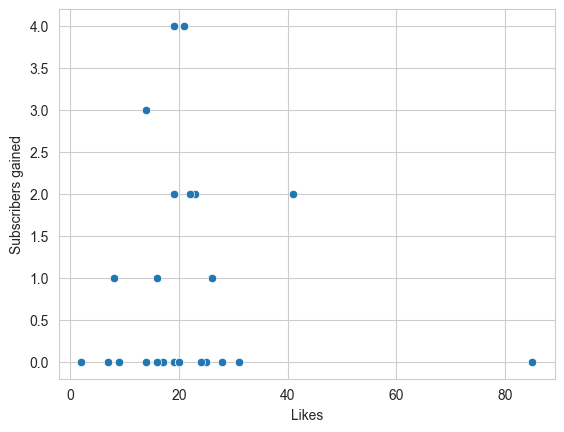

In [ ]:
## Does engagement drive growth?

sns.scatterplot(x='Likes', y='Subscribers gained', data=df)

Insight: Do emotional videos convert better? Relatability? Topic?

<Axes: xlabel='Impressions click-through rate (%)', ylabel='Views'>

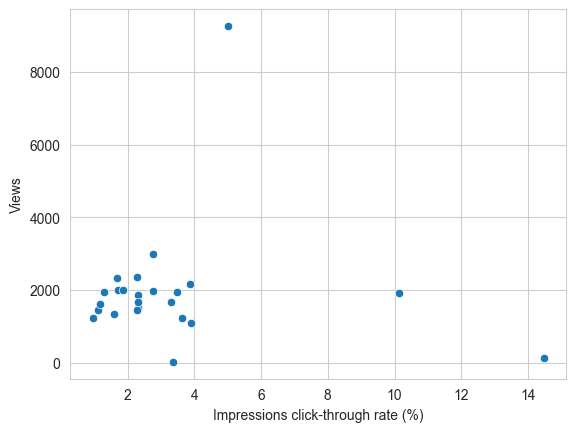

In [ ]:
## CTR vs Performance

sns.scatterplot(x='Impressions click-through rate (%)', y='Views', data=df)

Insight: Good title ≠ good content always.

<Axes: xlabel='publish_day'>

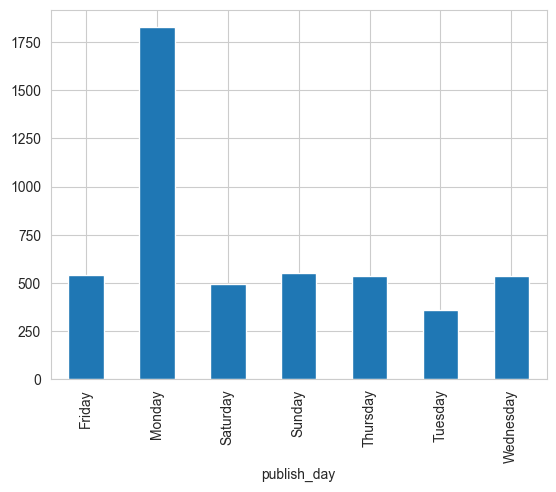

In [ ]:
## When should you post?
df.groupby('publish_day')['Engaged views'].mean().plot(kind='bar')
Insight: Best day to post

In [39]:
## KEY METRICS

#Engagement Rate
df['engagement_rate'] = (df['Likes'] + df['Comments added'] + df['Shares']) / df['Views']

df[['Video title', 'Views', 'Likes', 'Comments added', 'Shares', 'engagement_rate']].head()




,Video title,Views,Likes,Comments added,Shares,engagement_rate
1,Ever Craved Something SO Bad… But Then It Tast...,9264,85,3,0,0.009499
2,Some People Just Bring Good Energy,1512,19,3,0,0.014550
3,Love is remembering little things ❤️ #relatable,1873,20,2,0,0.011746
4,The Beauty of Unexpected Kindness,2173,23,3,1,0.012425
5,Just Because You’re Different Doesn’t Mean You...,1940,19,2,0,0.010825


In [105]:
## Conversion Analysis
df['conversion_rate'] = df['Subscribers gained'] / df['Engaged views']

In [102]:
df.sort_values(by='conversion_rate', ascending=False)[['Video title','conversion_rate']]

,Video title,conversion_rate
19,Tiny Train Ride Down Penang Hill 🇲🇾 | Malaysia...,0.007707
6,When you start celebrating the little things l...,0.007181
17,When Gossip Drains Your Energy,0.005725
20,"You Are Not Your Thoughts, Read This Twice",0.003891
7,A Reminder: You Still Matter,0.003610
5,Just Because You’re Different Doesn’t Mean You...,0.003559
4,The Beauty of Unexpected Kindness,0.003460
18,A Painful Truth About Being the Easy Target. ...,0.001908
13,Some Friendships Feel Like Sunshine,0.001873
12,One of the Most Beautiful Views I’ve Seen.,0.001866


### Conversion Insights

Some videos with moderate views show higher conversion rates → indicates strong audience connection  
High-view videos do not necessarily convert into subscribers  
Emotional / relatable content appears to have better conversion efficiency  
Several videos have 0 conversion → content may lack call-to-action or impact  
A large number of videos resulted in zero subscriber conversion, suggesting weak content-to-subscription funnel
Conversion rate defined as: Subscribers gained per engaged viewer
conversion_rate = Subscribers gained / Engaged views

In [ ]:
### Hypothesis

Videos that are emotionally relatable or story-based tend to convert better into subscribers compared to generic or informational content.

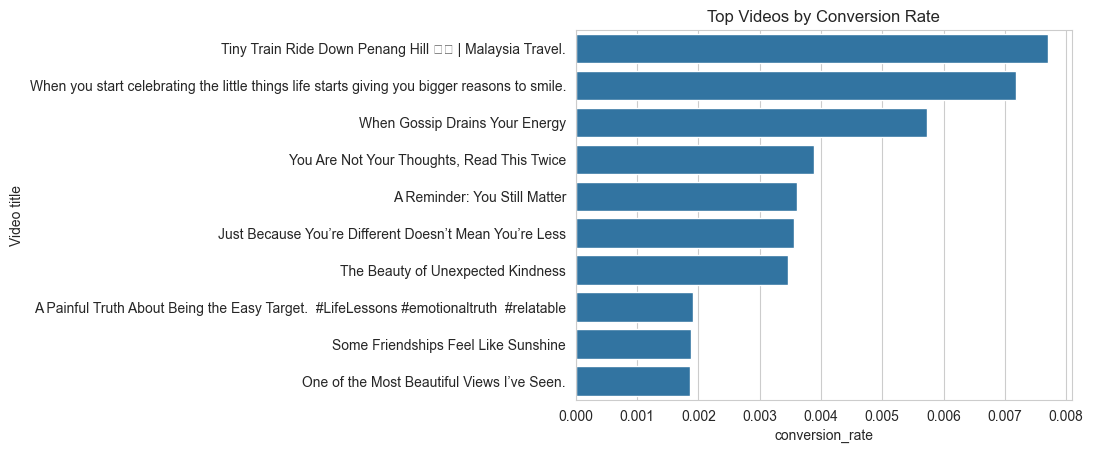

In [103]:
sns.barplot(x='conversion_rate', y='Video title', data=df.sort_values(by='conversion_rate', ascending=False).head(10))
plt.title("Top Videos by Conversion Rate")
plt.show()

## Insight Recommendations

- Focus on emotionally relatable content → higher engagement
- Improve conversion strategy → high views but low subscribers
- Optimize posting day (Monday shows peak performance)
- Improve thumbnails/titles → CTR does not guarantee views

## Limitations

- Dataset is limited to one month (March 2026)
- Small sample size (24 videos)
- External factors like algorithm changes not considered
- Content categories not explicitly labeled

## Final Conclusion

- This analysis shows that YouTube Shorts performance is driven more by content relatability and audience retention than just views or impressions.

- While some videos achieved high reach, they failed to convert into subscribers, indicating a gap in content-to-conversion strategy.

- Optimizing for emotional connection, timing, and engagement quality can significantly improve channel growth.

In [106]:
df.to_csv('youtube_shorts_march_2026.csv', index=False)